¡Carga y procesamiento de datos para América completado!


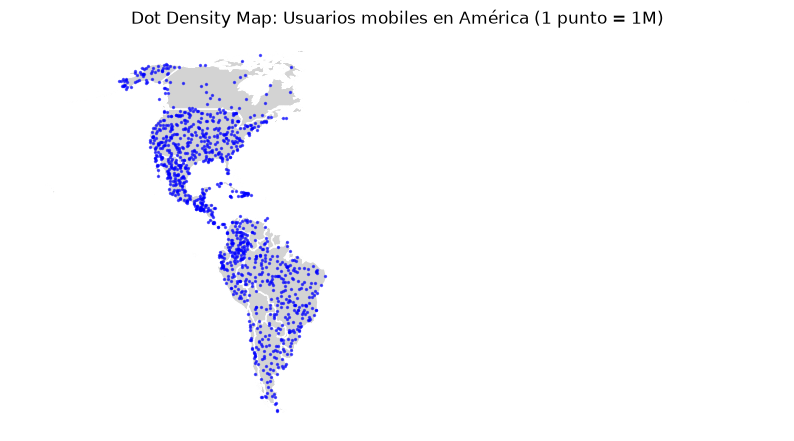

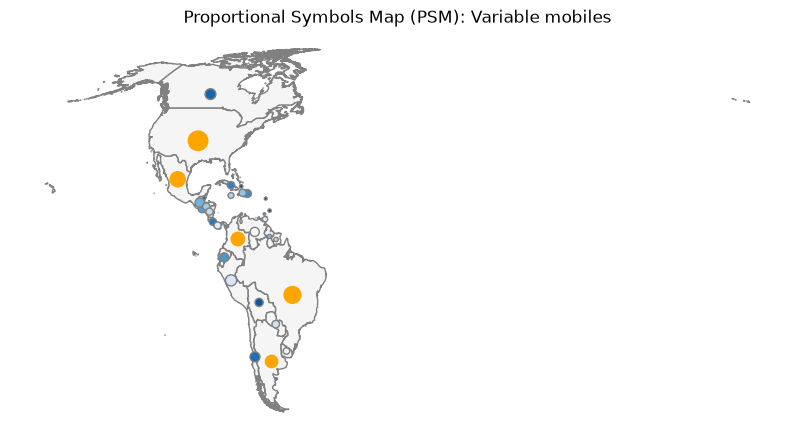

C:\Anaconda\anaconda2\envs\Tres_doce_Datos_Espaciales\Lib\site-packages\geopandas\plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


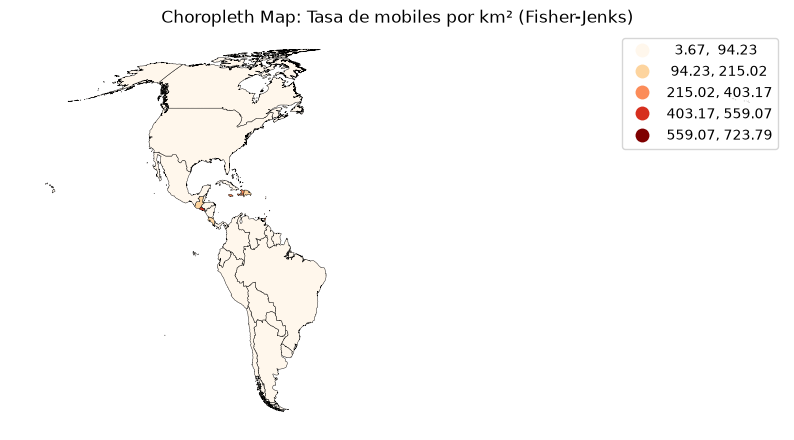

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from thefuzz.process import extractOne as best

# 1. Rutas de acceso a GitHub Raw
linkGit = 'https://raw.githubusercontent.com/TareasDatosEspaciales/MOBILES/main/'
someDataLink = 'some_dataworld.csv'

# 2. Carga de archivos
countries = gpd.read_file('worldMaps.gpkg', layer='countries')
someData = pd.read_csv(linkGit + someDataLink)

# 3. Homogeneización del nombre de la columna para la fusión
countries.rename(columns={'COUNTRY': 'Country'}, inplace=True)
countries['Country'] = countries.Country.str.upper()

# 4. Ajuste difuso de nombres de países (Fuzzy Matching)
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)
changesToDF = {country: best(country, onlyGDF)[0] for country in onlyDF}
someData.replace(to_replace={'Country': changesToDF}, inplace=True)

# 5. Fusión de datos y filtrado para América y el Caribe
theMapAndData = countries.merge(someData, on='Country')
regiones_america = ['NORTH AMERICA', 'SOUTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN']
America = theMapAndData[theMapAndData.region.isin(regiones_america)].copy()

# 6. Reproyección a sistema de área equivalente (World Mercator Equal Area)
America_8857 = America.to_crs(8857)

print("¡Carga y procesamiento de datos para América completado!")
np.random.seed(12345) # Semilla fija para reproducibilidad

# Función para generar puntos dentro de los polígonos según la variable 'mobiles'
def gen_points(gdf, col_name, factor=1_000_000):
    points = []
    for idx, row in gdf.iterrows():
        num_points = int(row[col_name] / factor)
        if num_points > 0:
            minx, miny, maxx, maxy = row.geometry.bounds
            cnt = 0
            while cnt < num_points:
                pnt = gpd.points_from_xy([np.random.uniform(minx, maxx)], [np.random.uniform(miny, maxy)])[0]
                if row.geometry.contains(pnt):
                    points.append(pnt)
                    cnt += 1
    return gpd.GeoDataFrame(geometry=points, crs=gdf.crs)

# Generación de puntos (1 punto = 1,000,000 de usuarios mobiles)
dots = gen_points(America_8857, 'mobiles', factor=1000000)

# Graficar DDM
fig, ax = plt.subplots(figsize=(10, 10))
America_8857.plot(ax=ax, color='lightgrey', edgecolor='white')
dots.plot(ax=ax, color='blue', markersize=2, alpha=0.6)
plt.title("Dot Density Map: Usuarios mobiles en América (1 punto = 1M)")
plt.axis('off')
plt.show()
# Cálculo de puntos representativos (centroides estables)
America_8857_centroids = America_8857.copy()
America_8857_centroids["geometry"] = America_8857.representative_point()

# Identificación de outliers para la variable 'mobiles'
boxplotInfo = America_8857_centroids.boxplot(column='mobiles', return_type="dict")
outliers = boxplotInfo['fliers'][0].get_ydata()
plt.close()

# Clasificación binaria de outliers
America_8857_centroids['mobiles_outlier'] = America_8857_centroids.mobiles.isin(outliers) * 1
America_out = America_8857_centroids[America_8857_centroids.mobiles_outlier == 1].copy()
America_no_out = America_8857_centroids[America_8857_centroids.mobiles_outlier == 0].copy()

# Ajuste del tamaño de símbolos usando raíz cuadrada
America_out['size'] = America_out['mobiles'].apply(lambda x: x**0.5 / 100)
America_no_out['size'] = America_no_out['mobiles'].apply(lambda x: x**0.5 / 100)

# Graficar PSM
base = America_8857.plot(color='whitesmoke', edgecolor='grey', figsize=(10, 10))
America_no_out.plot(
    ax=base,
    markersize=America_no_out['size'],
    edgecolor='grey',
    c=America_no_out['size'],
    cmap='Blues_r'
)
America_out.plot(
    ax=base,
    markersize=America_out['size'],
    color='orange'
)
plt.title("Proportional Symbols Map (PSM): Variable mobiles")
plt.axis('off')
plt.show()
# Cálculo de densidad: tasa de usuarios mobiles por km²
America_8857['mobiles_rate'] = America_8857['mobiles'] / (America_8857.geometry.area / 10**6)

# Graficar mapa coroplético con clasificación de Fisher-Jenks (5 clases)
fig, ax = plt.subplots(figsize=(10, 10))
America_8857.plot(
    column='mobiles_rate',
    scheme='FisherJenks',
    k=5,
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)
plt.title("Choropleth Map: Tasa de mobiles por km² (Fisher-Jenks)")
plt.axis('off')
plt.show()